In [ ]:
#here i will run everything

In [5]:
import geopandas as gpd
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from rasterio.windows import Window

In [21]:
import xarray as xr

ds = xr.open_dataset("../data/raw/Landsat/LandsatComposite_Zurich_1985.tif", engine="rasterio")
ds
red = ds.band_data.sel(band=3)
nir = ds.band_data.sel(band=4)
thermal = ds.band_data.sel(band=7)

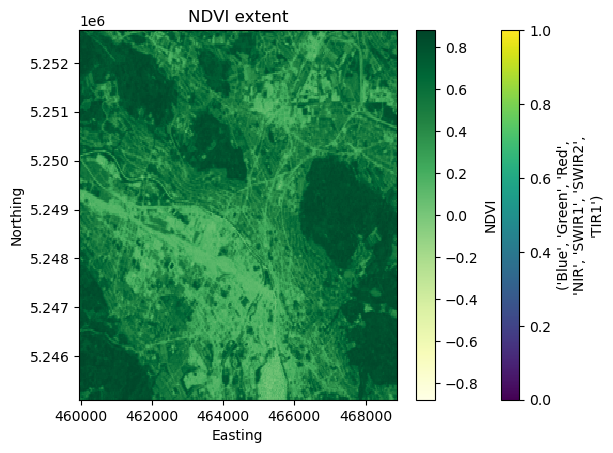

In [16]:
ndvi = (nir - red) / (nir + red)
ndvi = ndvi.where((nir + red) != 0)
ndvi = ndvi.clip(min=-1, max=1)

ndvi.name = "NDVI"
ndvi.attrs = {"long_name": "NDVI"}

ndvi.plot(cmap="YlGn", center = 0)
plt.title("NDVI extent")
plt.ylabel("Northing")
plt.xlabel("Easting")
plt.show()

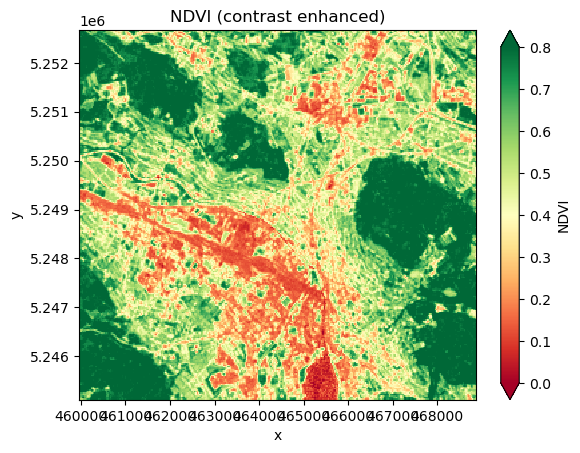

In [18]:
ndvi.plot(cmap="RdYlGn", vmin=0, vmax=0.8)
plt.title("NDVI (contrast enhanced)")
plt.show()

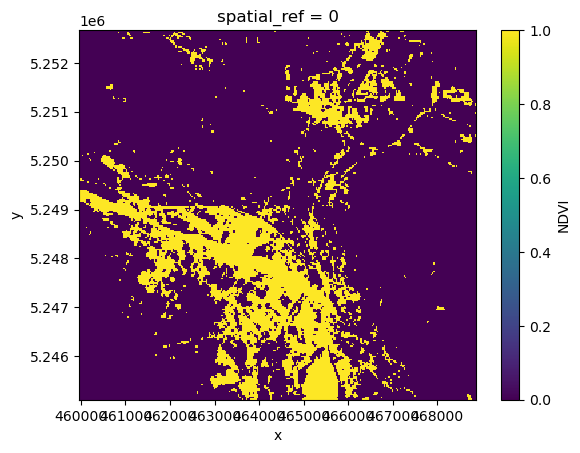

In [17]:
urban_mask = ndvi < 0.3
veg_mask = ndvi > 0.5

urban_mask.plot()

Temp min: 18.88217393000002
Temp max: 45.73584806000002


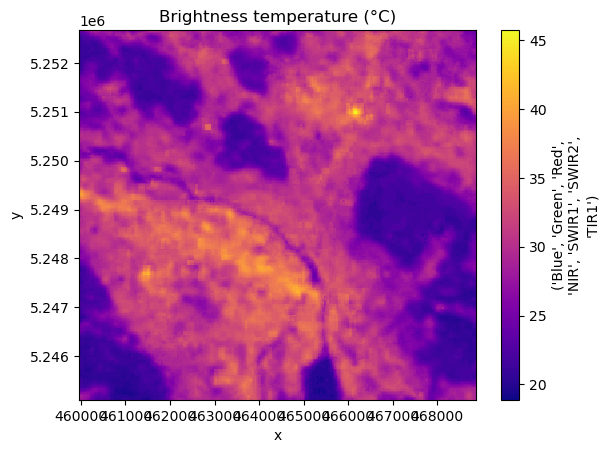

In [19]:
thermal_k = thermal         
thermal_c = thermal_k - 273.15

thermal_c.name = "Temperature"
thermal_c.attrs = {"long_name": "Brightness temperature (°C)"}

#ndvi based emissivity, 
veg_prop = ((ndvi - ndvi.min()) / (ndvi.max() - ndvi.min())) ** 2
emissivity = 0.004 * veg_prop + 0.986

#compute LST
BT = thermal_k  # already Kelvin

lambda_ = 11.45e-6
rho = 1.438e-2

lst = BT / (1 + (lambda_ * BT / rho) * np.log(emissivity))
bt_c = thermal_k - 273.15

print("Temp min:", float(bt_c.min()))
print("Temp max:", float(bt_c.max()))

bt_c.plot(cmap="plasma")
plt.title("Brightness temperature (°C)")
plt.show()



In [36]:
# --- Raster metadata ---
with rasterio.open(filepath) as src:
    print("File:", src.name)
    print("Mode:", src.mode)
    print("Number of bands:", src.count)
    print("Width:", src.width)
    print("Height:", src.height)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)

File: ../data/raw/Landsat/LandsatComposite_Zurich_1985.tif
Mode: r
Number of bands: 7
Width: 297
Height: 252
CRS: EPSG:32632
Bounds: BoundingBox(left=459960.0, bottom=5245110.0, right=468870.0, top=5252670.0)
